# **Exercises:**

# **Starting**

Exercises

**Q1 What Linear Regression training algorithm can you use if you have a training set with millions of features?**


**Ans:** Mini Batch SGD algorithm will best for this problem because feature are in million so it will use mini batches for training.

---------------------------------------------------------------------------
**Q2. Suppose the features in your training set have very different scales. What algo‐rithms might suffer from this, and how? What can you do about it?**


**Ans:** Having features in your training set very different scales will affect the Grident like age(0 to 120) and income (100k to 10000k) one add large learning in grident and other will add less learning into weights and also affect l1 and l2 regularizer so on.

the thing we can do in it, is to use Standard Scaler or Normalization.


------------------------------------------------------------
**Q3. Can Gradient Descent get stuck in a local minimum when training a Logistic Regression model?**

**Ans:** 
No, standard logistic regression does not have local minima for gradient descent to get stuck in.






**Q4. Do all Gradient Descent algorithms lead to the same model provided you let them run long enough?**

Running long enough does not guarantee all gradient descent algorithms reach the exact same model.

In convex optimization → mostly yes

In deep learning/non-convex optimization → usually not


**Q5. Suppose you use Batch Gradient Descent and you plot the validation error at every epoch. If you notice that the validation error consistently goes up, what is likely going on? How can you fix this?**

**Ans:** If the validation error consistently increases while training error decreases, the model is likely overfitting. The model learns the training data too specifically and fails to generalize to unseen data. This can be fixed using techniques such as early stopping, regularization, reducing model complexity, dropout, or increasing the amount of training data.


**6. Is it a good idea to stop Mini-batch Gradient Descent immediately when the vali‐dation error goes up?**

**Ans:** No, it is not a good idea to stop Mini-batch Gradient Descent immediately when the validation error goes up. Since Mini-batch GD trains on small batches, the validation error may fluctuate up and down due to noisy updates. A temporary increase does not necessarily mean the model has stopped improving. Therefore, we should wait for several epochs before stopping training.

**Q7. Which Gradient Descent algorithm (among those we discussed) will reach the vicinity of the optimal solution the fastest? Which will actually converge? How can you make the others converge as well?**

**Ans:** Mini-batch GD is considered the “best practical optimizer” because it balances:

- speed
- memory efficiency
- stability

That is why it is heavily used in deep learning.

**Q8. Suppose you are using Polynomial Regression. You plot the learning curves and you notice that there is a large gap between the training error and the validation error. What is happening? What are three ways to solve this?**

**Ans:** A large gap between training error and validation error in Polynomial Regression indicates overfitting. The model fits the training data very well but fails to generalize to unseen data. This usually happens when the polynomial degree is too high. Three ways to solve this are:

Reduce the polynomial degree,
Apply regularization such as Ridge or Lasso,
Increase the amount of training data.

**Q9. Suppose you are using Ridge Regression and you notice that the training error and the validation error are almost equal and fairly high. Would you say that the model suffers from high bias or high variance? Should you increase the regularization hyperparameter α or reduce it?**

**Ans:** The model suffers from high bias (underfitting) because both the training error and validation error are high and nearly equal. In Ridge Regression, this can happen if the regularization parameter α is too large, making the model too simple. To fix this, we should reduce α so the model can fit the data better.

**Q10. Why would you want to use:

• Ridge Regression instead of Linear Regression?

• Lasso instead of Ridge Regression?

• Elastic Net instead of Lasso?**

**Ans:** Ridge Regression is preferred over Linear Regression because it reduces overfitting by shrinking coefficient values using L2 regularization.

Lasso is preferred over Ridge Regression because it can perform feature selection by forcing some coefficients exactly to zero using L1 regularization.

Elastic Net is preferred over Lasso because it combines both L1 and L2 regularization, providing feature selection while also handling highly correlated features more effectively.

-----------------------

3. Elastic Net

Elastic Net combines BOTH penalties.

Formula:

J(w)=Loss+λ
1
	​

(∣w∣)+λ
2
	​

(w
2
)

J(w)=Loss+λ
1
	​

(∣w∣)+λ
2
	​

(w
2
)

Expanded:

J(w)=Loss+λ
1
	​

(∣w
1
	​

∣+∣w
2
	​

∣)+λ
2
	​

(w
1
2
	​

+w
2
2
	​

)

Suppose:

λ
1
	​

=1,λ
2
	​

=1

For:

w
1
	​

=8,w
2
	​

=2

L1 part:

∣8∣+∣2∣=10

L2 part:

8
2
+2
2
=68

Total:

J(w)=10+10+68=88
What Elastic Net does

It:

shrinks large weights (Ridge behavior)
removes useless features (Lasso behavior)

So you get:

stability of Ridge
feature selection of Lasso
Practical intuition

Imagine 100 features.

Ridge

Keeps all 100 features but shrinks them.

Lasso

May keep only:

15 useful features
remove 85 features
Elastic Net

Selects important features while keeping correlated features more stable.


**Q11. Suppose you want to classify pictures as outdoor/indoor and daytime/nighttime. Should you implement two Logistic Regression classifiers or one Softmax Regression classifier?**

**Ans:** We should use two Logistic Regression classifiers instead of one Softmax Regression classifier. This is because the problem is multi-label, not multiclass. An image can belong to both categories simultaneously, such as “outdoor and nighttime.” One Logistic Regression classifier can predict indoor/outdoor, while the second predicts daytime/nighttime independently.

**Q12. Implement Batch Gradient Descent with early stopping for Softmax Regression (without using Scikit-Learn).**


In [53]:
import pandas as pd
import numpy as np 

df = pd.read_csv(r"/home/noneo/Codes/ML/MachineLearning/Hand_On_ML/insurance.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt



In [55]:
from sklearn.preprocessing import LabelEncoder

le_sex = LabelEncoder()
le_smoker = LabelEncoder()

df['sex'] = le_sex.fit_transform(df['sex'])
df['smoker'] = le_smoker.fit_transform(df['smoker'])



In [56]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

encoded = ohe.fit_transform(df[['region']], )

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=ohe.get_feature_names_out(['region'])
)

df = df.drop('region', axis=1)

df = pd.concat([df, encoded_df], axis=1)

In [57]:
X = df.drop('expenses', axis=1)
y = df['expenses']

X_train, X_test, y_train, y_test =   train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
df

,age,sex,bmi,children,smoker,expenses,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.9,0,1,16884.92,0.0,0.0,0.0,1.0
1,18,1,33.8,1,0,1725.55,0.0,0.0,1.0,0.0
2,28,1,33.0,3,0,4449.46,0.0,0.0,1.0,0.0
3,33,1,22.7,0,0,21984.47,0.0,1.0,0.0,0.0
4,32,1,28.9,0,0,3866.86,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,31.0,3,0,10600.55,0.0,1.0,0.0,0.0
1334,18,0,31.9,0,0,2205.98,1.0,0.0,0.0,0.0
1335,18,0,36.9,0,0,1629.83,0.0,0.0,1.0,0.0
1336,21,0,25.8,0,0,2007.95,0.0,0.0,0.0,1.0


In [59]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [60]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [61]:
epochs = 100
batch_size = 32
learning_rate = 0.1
m, n  = X_train.shape

loss = []
w = np.zeros(n)

for epoch in range(epochs):
    
    indices = np.arange(m)
    np.random.shuffle(indices)
    
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    for i in range(0, m, batch_size):
        
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        y_pred = sigmoid(np.dot(X_batch, w))
        
        error = y_pred - y_batch

        gradient = np.dot(X_batch.T, error) / len(X_batch)
        
        w -= learning_rate * gradient
        
    y_pred = sigmoid(np.dot(X_train, w))
    
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    e_loss = - (1 / m) * np.sum(
        y_train * np.log(y_pred) +
        (1 - y_train) * np.log(1 - y_pred)
    )

    loss.append(e_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Current Log Loss: {e_loss:.5f}")


z_test = np.dot(X_test, w)

test_probabilities = sigmoid(z_test)

test_predictions = (test_probabilities >= 0.5).astype(int)



Epoch 001/100 | Current Log Loss: -460933.74566
Epoch 010/100 | Current Log Loss: -460933.74566
Epoch 020/100 | Current Log Loss: -460933.74566
Epoch 030/100 | Current Log Loss: -460933.74566
Epoch 040/100 | Current Log Loss: -460933.74566
Epoch 050/100 | Current Log Loss: -460933.74566
Epoch 060/100 | Current Log Loss: -460933.74566
Epoch 070/100 | Current Log Loss: -460933.74566
Epoch 080/100 | Current Log Loss: -460933.74566
Epoch 090/100 | Current Log Loss: -460933.74566
Epoch 100/100 | Current Log Loss: -460933.74566


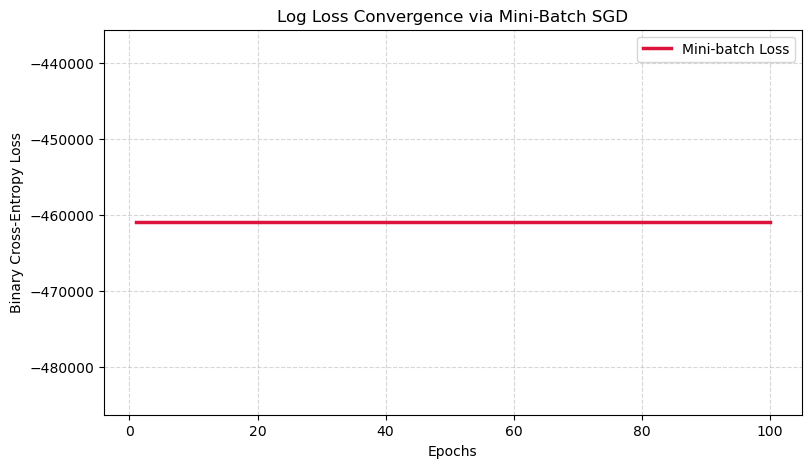

In [62]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), loss, color='crimson', lw=2.5, label='Mini-batch Loss')
plt.title('Log Loss Convergence via Mini-Batch SGD')
plt.xlabel('Epochs')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()